In [28]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [29]:
#load dataset
df = pd.read_csv("data/superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [30]:
#data understanding
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [31]:
#data understanding
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [32]:
df.isnull().sum

<bound method DataFrame.sum of       Row ID  Order ID  Order Date  Ship Date  Ship Mode  Customer ID  \
0      False     False       False      False      False        False   
1      False     False       False      False      False        False   
2      False     False       False      False      False        False   
3      False     False       False      False      False        False   
4      False     False       False      False      False        False   
...      ...       ...         ...        ...        ...          ...   
9989   False     False       False      False      False        False   
9990   False     False       False      False      False        False   
9991   False     False       False      False      False        False   
9992   False     False       False      False      False        False   
9993   False     False       False      False      False        False   

      Customer Name  Segment  Country   City  ...  Postal Code  Region  \
0             Fals

In [33]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df.info

<bound method DataFrame.info of       Row ID        Order ID Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156 2016-11-08  11/11/2016    Second Class   
1          2  CA-2016-152156 2016-11-08  11/11/2016    Second Class   
2          3  CA-2016-138688 2016-06-12   6/16/2016    Second Class   
3          4  US-2015-108966 2015-10-11  10/18/2015  Standard Class   
4          5  US-2015-108966 2015-10-11  10/18/2015  Standard Class   
...      ...             ...        ...         ...             ...   
9989    9990  CA-2014-110422 2014-01-21   1/23/2014    Second Class   
9990    9991  CA-2017-121258 2017-02-26    3/3/2017  Standard Class   
9991    9992  CA-2017-121258 2017-02-26    3/3/2017  Standard Class   
9992    9993  CA-2017-121258 2017-02-26    3/3/2017  Standard Class   
9993    9994  CA-2017-119914 2017-05-04    5/9/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute

In [34]:
#Sales by category
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

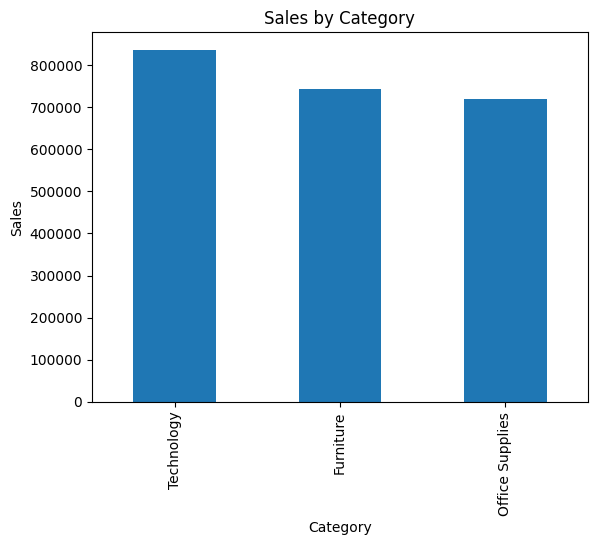

In [35]:
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

In [36]:
df["month"] = df["Order Date"].dt.to_period("M")
monthly_sales = df.groupby("month")["Sales"].sum()
monthly_sales.head()

month
2014-01    14236.895
2014-02     4519.892
2014-03    55691.009
2014-04    28295.345
2014-05    23648.287
Freq: M, Name: Sales, dtype: float64

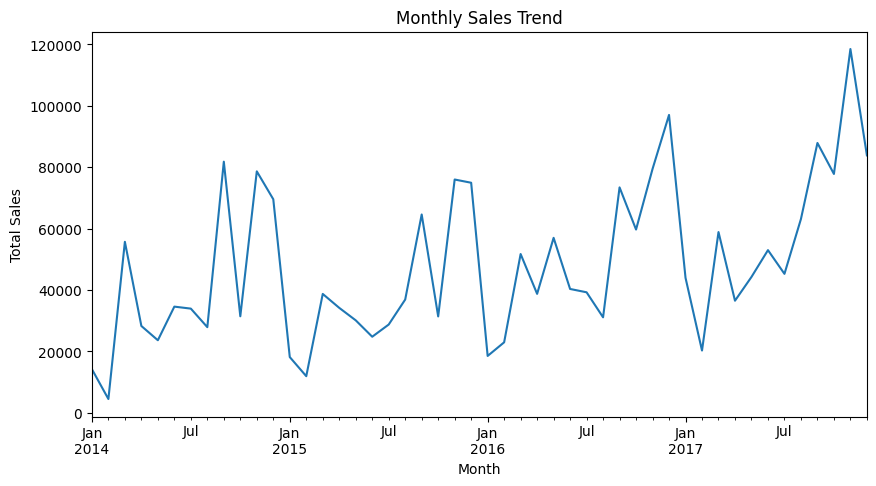

In [37]:
#visualization for growth patterns
monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

In [38]:
#top selling products
top_products = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending = False)
top_products.head(10)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64

Text(0.5, 0, 'Product Category')

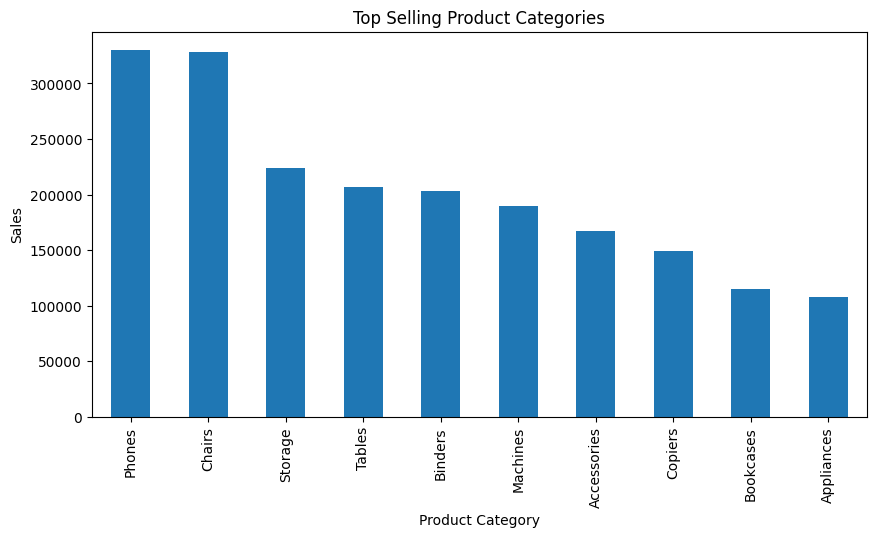

In [39]:
#visualization of top products
top_products.head(10).plot(kind = "bar", figsize=(10,5))

plt.title("Top Selling Product Categories")
plt.ylabel("Sales")
plt.xlabel("Product Category")

In [40]:
#finding which region perform the best
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending = False)
region_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

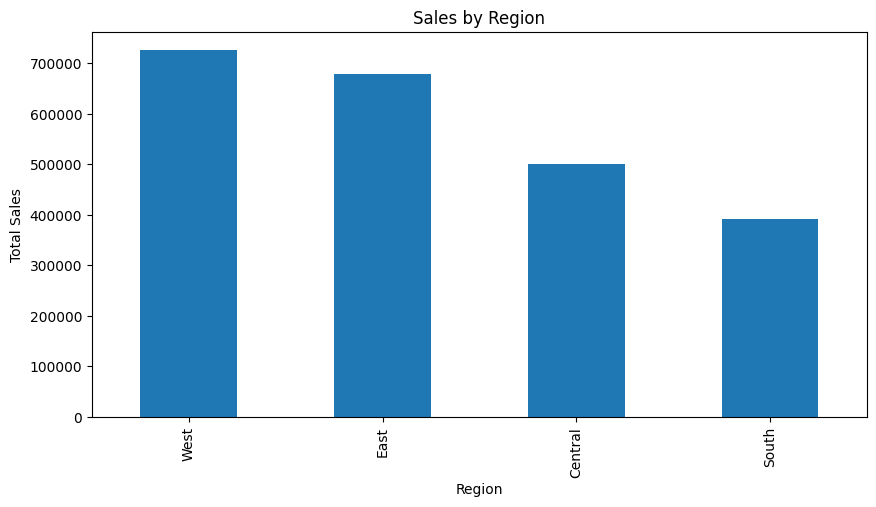

In [41]:
region_sales.plot(kind = "bar", figsize=(10,5))
plt.title("Sales by Region")
plt.ylabel("Total Sales")
plt.xlabel("Region")

plt.show()

INSIGHTS

- Technology products create the the highest overall sales.
- Sales icreased significantly towards the end of 2017.
- Phones, chairs, and storage are the highest performing sub-categories(top 3).
- The West produces the highest sales while the South produces the lowest.


In [52]:
#Summary of results
analysis_summary = f"""
Total Sales: {df["Sales"].sum()}

Top Product Categories: {top_products.head(5)}

Sales by Region: {region_sales}

Recent Monthly Sales: {monthly_sales.tail(3)}
"""

print(analysis_summary)


Total Sales: 2297200.8603

Top Product Categories: Sub-Category
Phones     330007.054
Chairs     328449.103
Storage    223843.608
Tables     206965.532
Binders    203412.733
Name: Sales, dtype: float64

Sales by Region: Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

Recent Monthly Sales: month
2017-10     77776.9232
2017-11    118447.8250
2017-12     83829.3188
Freq: M, Name: Sales, dtype: float64



In [56]:
def mock_ai_insights(summary_text):
    return f"""
Based on the sales data summary:

1. Total sales are strong, with Phones and Chairs being the top contributors.
2. West and East regions generate the majority of revenue — consider expanding marketing or stock there.
3. Recent monthly sales show October-November peaks — possibly due to seasonal trends.
4. Storage, Tables, and Binders are underperforming relative to top products — investigate promotions or pricing.
"""

ai_insights = mock_ai_insights(analysis_summary)
print(ai_insights)


Based on the sales data summary:

1. Total sales are strong, with Phones and Chairs being the top contributors.
2. West and East regions generate the majority of revenue — consider expanding marketing or stock there.
3. Recent monthly sales show October-November peaks — possibly due to seasonal trends.
4. Storage, Tables, and Binders are underperforming relative to top products — investigate promotions or pricing.

